In [2]:
import numpy as np
import pickle
from qiskit_nature.second_q.operators import SpinOp
from qiskit_nature.second_q.mappers import LogarithmicMapper
n_qubit = 1
dim     = 2**n_qubit
mapper = LogarithmicMapper()
t = 0.5
nld = 11
lds = np.linspace(0,1,num=nld)
Hld = []
i = 0
for ld in lds:
    h = SpinOp({
        "X_0": t,  
        "Z_0": -1.0 + 2.0* ld
    },
    spin=1/2
    )
    Hld.append(2*mapper.map(h.simplify())) # 2 is due to spin 1/2
    #print(Hld[i])
    i +=1
h = SpinOp({
    "Z_0": 2.0
},
spin=1/2
)
Hp = 2*mapper.map(h.simplify()) # 2 is due to spin 1/2

from qiskit import QuantumRegister
from qiskit import QuantumCircuit

qr = QuantumRegister(n_qubit+1, 'q')

# exact eigenvalues
ell  = np.zeros((nld,dim),dtype=float)
vll  = np.zeros((nld,dim,dim),dtype=complex)
for ild in range(nld):
    El, Vl = np.linalg.eigh(Hld[ild].to_matrix())
    indx = np.argsort(El.real)
    for i in range(dim):
        ell[ild,i]   = El[indx[i]].real
        vll[ild,:,i] = Vl[:,indx[i]]
# exact results
norm_exact   = np.ones((nld,dim),dtype=float)
E_exact      = np.zeros((nld,dim),dtype=float)
E_exact[0,:] = ell[0,:]
for k in range(dim):
    phi = vll[0,:,k]
    for ild in range(1,nld):
        Proj_matrix = np.outer(vll[ild,:,k],vll[ild,:,k].conj())
        phi = Proj_matrix@phi
        norm_exact[ild,k] = phi.conj()@phi
        E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]

/tmp/ipykernel_1538/3925367095.py:53: ComplexWarning: Casting complex values to real discards the imaginary part
  norm_exact[ild,k] = phi.conj()@phi
/tmp/ipykernel_1538/3925367095.py:54: ComplexWarning: Casting complex values to real discards the imaginary part
  E_exact[ild,k] = phi.conj()@Hld[ild].to_matrix()@phi/norm_exact[ild,k]


In [3]:
def ComputeUnitaryParams(U):
    theta = 2.0 * np.arccos(np.abs(U[0,0]))
    if (theta<1E-6):
        theta = 2.0*np.arcsin(np.abs(U[0,1]))
    gamma = np.angle(U[0,0])
    if (theta<1E-10):
        phi   = np.angle(U[1,1]/U[0,0])
        lam   = 0
    else:
        phi   = np.angle(U[1,0]/np.sin(theta/2)) - gamma
        lam   = np.angle(-U[0,1]/np.sin(theta/2)) - gamma
    return theta, phi, lam, gamma
import copy
X = np.zeros((2,2),dtype=complex)
Y = np.zeros((2,2),dtype=complex)
Z = np.zeros((2,2),dtype=complex)

X[0,1] = 1; X[1,0] = 1
Y[0,1] = -1j; Y[1,0] = 1j
Z[0,0] = 1; Z[1,1] = -1


def ExactTimeEvolution (ild, time):
    Vl = copy.deepcopy(vll[ild,:,:])
    evol = np.zeros((dim,dim),dtype=complex)
    exp_d = np.diag(np.exp(-1j*ell[ild,:]*time))
    evol = Vl@exp_d@Vl.conj().T
    return evol

def TrotterTimeEvolution (ild, Nt, time):
    dtime  = time/Nt
    dtx = dtime * t
    dtz = dtime * (2*lds[ild]-1)
    evol = np.identity(dim)
    for it in range(Nt):
        evol_X = np.cos(dtx)*np.identity(dim) - 1j*np.sin(dtx) * X
        evol_Z = np.cos(dtz)*np.identity(dim) - 1j*np.sin(dtz) * Z
        evol = evol_Z@evol
        evol = evol_X@evol
    return evol

In [4]:
nmc = int(4E2)
nshot = 4000
beta     = 5
Emc      = np.zeros((nld,dim),dtype=float)
normmc   = np.zeros((nld,dim),dtype=float)
dE1norm_raw = np.zeros((nmc,nld,dim),dtype=float)
normmc_raw = np.zeros((nmc,nld,dim),dtype=float)

In [5]:

# exact simulator, exact time evolution, dE version
from qiskit import transpile, Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import ParameterVector
from qiskit_aer.primitives import Estimator as AerEstimator
import random as rd
import copy

observable = SparsePauliOp('IZ')
estimator = AerEstimator(run_options={"shots":nshot})
backend = Aer.get_backend('aer_simulator')

params = ParameterVector('θ',5)


for k in range(dim):
    normmc[0,k]   = 1
    Emc[0,k]      = ell[0,k]
    eps = vll[0,:,k].conj().T@Hld[1].to_matrix()@vll[0,:,k] # first order perturbated energy
    eps = eps.real
    circuit = QuantumCircuit(qr, name='total_circuit')
    circuit.initialize(vll[0,:,k],qr[1:])
    circuit.h(qr[0])
    circuit.cu(params[0],params[1],params[2],params[3],qr[0],qr[1])
    circuit.rz(params[4],qr[0])
    circuit.h(qr[0])
    for ild in range(1,nld):
        norm     = 0.0
        dE1norm    = 0.0
        dE2norm   = 0.0
        t_list = []
        for imc in range(nmc):
            t_ = []
            for jld in range(1,ild):
                r = rd.gauss(0.0, 1.0)
                time = beta * r
                t_.append(time)
            r = rd.gauss(0.0, 1.0)
            time = beta * r
            t_.append(time)
            r = rd.gauss(0.0, 1.0)
            time = beta * r
            t_.append(time)
            for jld in reversed(range(1,ild)):
                r = rd.gauss(0.0, 1.0)
                time = beta * r
                t_.append(time)
            t_list.append(t_)

        params_list = []
        for imc in range(nmc):
            # norm measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + eps*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + eps*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol
            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])

        nhp = len(Hp)
        for ihp in range(nhp):
            # for the present iteration
            for imc in range(nmc):
                phase = 0.0
                U_evol = np.identity(2,dtype=complex)
                ind = 0
                for jld in range(1,ild):
                    time = t_list[imc][ind]
                    ind += 1
                    phase = phase + Emc[jld,k]*time
                    U_evol = ExactTimeEvolution(jld,time)@U_evol

                if (nhp==1):
                    Mat = Hp.to_pauli_op().to_matrix()/Hp.to_pauli_op().coeff
                else:
                    Mat = Hp.to_pauli_op()[ihp].to_matrix()/Hp.to_pauli_op()[ihp].coeff

                U_evol = Mat@U_evol

                time = t_list[imc][ind]
                ind += 1
                phase = phase + eps*time
                U_evol = ExactTimeEvolution(ild,time)@U_evol


                time = t_list[imc][ind]
                ind += 1
                phase = phase + eps*time
                U_evol = ExactTimeEvolution(ild,time)@U_evol

                for jld in reversed(range(1,ild)):
                    time = t_list[imc][ind]
                    ind += 1
                    phase = phase + Emc[jld,k]*time
                    U_evol = ExactTimeEvolution(jld,time)@U_evol
                theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)

                params_list.append([theta,phi,lam,gamma,phase])
        for ihp in range(nhp):
            # for the next iteration
            for imc in range(nmc):
                phase = 0.0
                U_evol = np.identity(2,dtype=complex)
                ind = 0
                for jld in range(1,ild):
                    time = t_list[imc][ind]
                    ind += 1
                    phase = phase + Emc[jld,k]*time
                    U_evol = ExactTimeEvolution(jld,time)@U_evol

                time = t_list[imc][ind]
                ind += 1
                phase = phase + eps*time
                U_evol = ExactTimeEvolution(ild,time)@U_evol

                if (nhp==1):
                    Mat = Hp.to_pauli_op().to_matrix()/Hp.to_pauli_op().coeff
                else:
                    Mat = Hp.to_pauli_op()[ihp].to_matrix()/Hp.to_pauli_op()[ihp].coeff
                U_evol = Mat@U_evol

                time = t_list[imc][ind]
                ind += 1
                phase = phase + eps*time
                U_evol = ExactTimeEvolution(ild,time)@U_evol

                for jld in reversed(range(1,ild)):
                    time = t_list[imc][ind]
                    ind += 1
                    phase = phase + Emc[jld,k]*time
                    U_evol = ExactTimeEvolution(jld,time)@U_evol
                theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)

                params_list.append([theta,phi,lam,gamma,phase])
        job = estimator.run([circuit]*nmc*(1+nhp+nhp), [observable]*nmc*(1+nhp+nhp), params_list)

        result = job.result()
        result_values = result.values

        for imc in range(nmc):
            normmc_raw[imc,ild,k] = result_values[imc]

        dE1norm_raw[:,ild,k] = 0.0
        for ihp in range(nhp):
            if (nhp==1):
                coeff = float(Hp.to_pauli_op().coeff)
            else:
                coeff = float(Hp.to_pauli_op()[ihp].coeff)
            for imc in range(nmc):
                dE1norm_raw[imc,ild,k] += coeff * result_values[nmc*(ihp+1)+imc]

        dE2norm = 0.0
        for ihp in range(nhp):
            if (nhp==1):
                coeff = float(Hp.to_pauli_op().coeff)
            else:
                coeff = float(Hp.to_pauli_op()[ihp].coeff)
            for imc in range(nmc):
                dE2norm += coeff * result_values[nmc*(ihp+nhp+1)+imc]

        norm    = 0.0
        dE1norm = 0.0
        for imc in range(nmc):
            norm += normmc_raw[imc,ild,k]
            dE1norm += dE1norm_raw[imc,ild,k]

        dE1   = dE1norm/norm
        dE2   = dE2norm/norm
        norm  = norm/nmc
        
        Emc[ild,k] = Emc[ild-1,k] + dE1 * (lds[ild]-lds[ild-1])
        normmc[ild,k] = norm

        if (ild<nld-1):
            eps = Emc[ild,k] + dE2*(lds[ild+1]-lds[ild])
        print(ild, norm, (Emc[ild,k]-ell[ild,k])/(ell[ild,k])*100)
        if (ild<nld-1):
            print(ild, norm, eps ,ell[ild+1,k])
        st = '# {i}/{dim}: {percent}%'.format(i=k+1,dim=dim,percent=((ild)/(nld-1)*100))
        print(st)

1 0.9973962500000019 -0.013479327281581802
1 0.9973962500000019 -0.7736813806465467 -0.7810249675906655
# 1/2: 10.0%
2 0.9924487500000012 -0.10316732796447513
2 0.9924487500000012 -0.6269596538149745 -0.6403124237432848
# 1/2: 20.0%
3 0.97884125 -0.3272716129920713
3 0.97884125 -0.5124089242224464 -0.5385164807134504
# 1/2: 30.0%
4 0.9441112500000004 -0.14967906488671587
4 0.9441112500000004 -0.46124963583152245 -0.5
# 1/2: 40.0%
5 0.8922137500000001 0.276619360294017
5 0.8922137500000001 -0.5043036413458688 -0.5385164807134505
# 1/2: 50.0%
6 0.8545775000000004 0.661097070376682
6 0.8545775000000004 -0.6177645835595464 -0.640312423743285
# 1/2: 60.0%
7 0.8675337499999989 0.7490387620840222
7 0.8675337499999989 -0.768310158909443 -0.7810249675906655
# 1/2: 70.0%
8 0.8699249999999994 0.8414682741901649
8 0.8699249999999994 -0.9449045714173514 -0.9433981132056604
# 1/2: 80.0%
9 0.8578550000000007 1.039544933802156
9 0.8578550000000007 -1.1244080444343367 -1.118033988749895
# 1/2: 90.0%
10

In [6]:
# standard deviation calculation with the bootstrap method
import random as rd
std_norm = np.zeros((nld,dim),dtype=float)
std_dE = np.zeros((nld,dim),dtype=float)
std_E = np.zeros((nld,dim),dtype=float)
n_boot = 1000
for k in range(dim):
    for ild in range(1,nld):
        norm_boot = np.zeros((n_boot),dtype=float)
        dE_boot   = np.zeros((n_boot),dtype=float)
        for i_boot in range(n_boot):
            norm_ = 0.0
            dE_   = 0.0
            for imc in range(nmc):
                jmc = rd.randrange(nmc)
                norm_ += normmc_raw[jmc,ild,k]
                dE_ += dE1norm_raw[jmc,ild,k]
            dE_   = dE_/norm_
            norm_ = norm_/nmc
            norm_boot[i_boot] = norm_
            dE_boot[i_boot] = dE_
        norm_boot_mean = 0.0
        dE_boot_mean   = 0.0
        for i_boot in range(n_boot):
            norm_boot_mean += norm_boot[i_boot]
            dE_boot_mean   += dE_boot[i_boot]
        norm_boot_mean /= n_boot
        dE_boot_mean /= n_boot

        var_norm = 0.0
        var_dE = 0.0
        for i_boot in range(n_boot):
            var_norm += (norm_boot[i_boot]-norm_boot_mean)**2
            var_dE += (dE_boot[i_boot]-dE_boot_mean)**2
        var_norm /= (n_boot-1)
        var_dE    /= (n_boot-1)
        std_norm[ild,k] = np.sqrt(var_norm)
        std_dE[ild,k] = np.sqrt(var_dE) * (lds[ild]-lds[ild-1])
        std_E[ild,k] = std_E[ild-1,k] + std_dE[ild,k]**2
for k in range(dim):
    for ild in range(1,nld):
        std_E[ild,k] = np.sqrt(std_E[ild,k])
        print(std_norm[ild,k],std_dE[ild,k],std_E[ild,k])

0.00010156924712705606 0.00016291644805213455 0.00016291644805213455
0.0003101285875274258 0.000360281099542649 0.00039540389443401287
0.0007682601115786685 0.0007084285857608425 0.0008113046905181132
0.0020580994381518454 0.0014117397741897288 0.0016282581155596793
0.004161569958812539 0.0025562850766603375 0.0030308114233720163
0.004946853121369638 0.003222467482342523 0.004423812220110305
0.005369896792293023 0.003336627895372441 0.005541046856955353
0.0053483932273032855 0.0028945754919104468 0.006251541213920244
0.006233066196171493 0.0027502033677976505 0.0068297427560332705
0.006615909569707365 0.002674022097781849 0.00733456067484717
0.00010138912813383322 0.0001629353553210984 0.0001629353553210984
0.00032123040196188125 0.0003998310038443076 0.00043175544194457965
0.0007656355942495782 0.0007624170046922924 0.0008761806039240576
0.0020553021195589614 0.0014318095988766172 0.0016786218091422336
0.00391653583190203 0.002444119767386459 0.0029650451287387154
0.005048829440632162

In [7]:
# save to file
with open('norm.E.save','w') as file_:
    s = '# λ , norm_k^2, std(norm_k^2), E_k, std(E_k), k= 1, .., dim'
    s += '\n'
    file_.write(s)
    for ild in range(nld):
        s = '{:.16e}'.format(lds[ild])
        for k in range(dim):
            s += '  {:.16e}  {:.16e}  {:.16e}  {:.16e}'.format(normmc[ild,k],std_norm[ild,k],Emc[ild,k],std_E[ild,k])
        s += '\n'
        file_.write(s)

In [21]:
# read from file
#Emc          = np.zeros((nld,dim),dtype=float)
#std_E        = np.zeros((nld,dim),dtype=float)
#normmc       = np.zeros((nld,dim),dtype=float)
#std_norm     = np.zeros((nld,dim),dtype=float)
#with open('norm.E.save','r') as file_:
#    ild = 0
#    for line in file_:
#        if line.startswith('#'):
#            continue
#        ls = line.split()
#        for k in range(dim):
#            normmc[ild,k]     = float(ls[k*4+1])
#            std_norm[ild,k]   = float(ls[k*4+2])
#            Emc[ild,k]        = float(ls[k*4+3])
#            std_E[ild,k]      = float(ls[k*4+4])
#        ild += 1

In [8]:
X_exact = np.zeros((nld,dim),dtype=float)
Y_exact = np.zeros((nld,dim),dtype=float)
Z_exact = np.zeros((nld,dim),dtype=float)
for ild in range(nld):
    for k in range(dim):
        X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
        Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
        Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]

/tmp/ipykernel_1538/361632611.py:6: ComplexWarning: Casting complex values to real discards the imaginary part
  X_exact[ild,k] = vll[ild,:,k].conj().transpose()@X@vll[ild,:,k]
/tmp/ipykernel_1538/361632611.py:7: ComplexWarning: Casting complex values to real discards the imaginary part
  Y_exact[ild,k] = vll[ild,:,k].conj().transpose()@Y@vll[ild,:,k]
/tmp/ipykernel_1538/361632611.py:8: ComplexWarning: Casting complex values to real discards the imaginary part
  Z_exact[ild,k] = vll[ild,:,k].conj().transpose()@Z@vll[ild,:,k]


In [ ]:
Xmc      = np.zeros((nld,dim),dtype=float)
Ymc      = np.zeros((nld,dim),dtype=float)
Zmc      = np.zeros((nld,dim),dtype=float)
Fmc      = np.zeros((nld,dim),dtype=float)

normmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Xnormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Ynormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Znormmc_raw = np.zeros((nmc,nld,dim),dtype=float)
Fnormmc_raw = np.zeros((nmc,nld,dim),dtype=float)

Xmc[0,:] = X_exact[0,:]
Ymc[0,:] = Y_exact[0,:]
Zmc[0,:] = Z_exact[0,:]
Fmc[0,:] = 1

In [13]:
# computation of the fidelity, <X>, <Y>, <Z>

# exact simulator, exact time evolution, dE version
from qiskit import transpile, Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import ParameterVector
from qiskit_aer.primitives import Estimator as AerEstimator
import random as rd
import copy

observable = SparsePauliOp('IZ')
estimator = AerEstimator(run_options={"shots":nshot})
backend = Aer.get_backend('aer_simulator')

params = ParameterVector('θ',5)




for k in range(1):
    circuit_real = QuantumCircuit(qr, name='circuit_for_real_part')
    circuit_real.initialize(vll[0,:,k],qr[1:])
    circuit_real.h(qr[0])
    circuit_real.cu(params[0],params[1],params[2],params[3],qr[0],qr[1])
    circuit_real.rz(params[4],qr[0])
    circuit_real.h(qr[0])

    #for ild in range(1,nld):
    for ild in range(nld-1,nld):
        t_list = []
        circuit_list = []
        for imc in range(nmc):
            t_ = []
            for jld in range(1,ild):
                r = rd.gauss(0.0, 1.0)
                time = beta * r
                t_.append(time)
            r = rd.gauss(0.0, 1.0)
            time = beta * r
            t_.append(time)
            r = rd.gauss(0.0, 1.0)
            time = beta * r
            t_.append(time)
            for jld in reversed(range(1,ild)):
                r = rd.gauss(0.0, 1.0)
                time = beta * r
                t_.append(time)
            t_list.append(t_)

        params_list = []
        for imc in range(nmc):
            # norm measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol
            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])
            circuit_list.append(circuit_real)

        for imc in range(nmc):
            # X measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            U_evol = X@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol
            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])
            circuit_list.append(circuit_real)

        for imc in range(nmc):
            # Y measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            U_evol = Y@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol
            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])
            circuit_list.append(circuit_real)

        for imc in range(nmc):
            # Z measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            U_evol = Z@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol
            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])
            circuit_list.append(circuit_real)

        #U_f = vll[0,:,:]@vll[ild,:,:].conj()
        U_f = 2.0*np.outer(vll[ild,:,k],vll[ild,:,k].conj())-np.identity(dim)

        for imc in range(nmc):
            # fidelity measurement
            phase = 0.0
            U_evol = np.identity(2,dtype=complex)
            ind = 0
            for jld in range(1,ild):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            U_evol = U_f@U_evol

            time = t_list[imc][ind]
            ind += 1
            phase = phase + Emc[ild,k]*time
            U_evol = ExactTimeEvolution(ild,time)@U_evol

            for jld in reversed(range(1,ild)):
                time = t_list[imc][ind]
                ind += 1
                phase = phase + Emc[jld,k]*time
                U_evol = ExactTimeEvolution(jld,time)@U_evol

            theta, phi, lam, gamma = ComputeUnitaryParams(U_evol)
            params_list.append([theta,phi,lam,gamma,phase])
            circuit_list.append(circuit_real)

        job = estimator.run(circuit_list, [observable]*nmc*5, params_list)

        result = job.result()
        result_values = result.values

        for imc in range(nmc):
            normmc_raw[imc,ild,k]  = result_values[imc]
            Xnormmc_raw[imc,ild,k] = result_values[nmc+imc]
            Ynormmc_raw[imc,ild,k] = result_values[2*nmc+imc]
            Znormmc_raw[imc,ild,k] = result_values[3*nmc+imc]
            Fnormmc_raw[imc,ild,k] = result_values[4*nmc+imc]

        norm   = 0.0
        Xnorm  = 0.0
        Ynorm  = 0.0
        Znorm  = 0.0
        Fnorm  = 0.0

        for imc in range(nmc):
            norm += normmc_raw[imc,ild,k]

        for imc in range(nmc):
            Xnorm += Xnormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Ynorm += Ynormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Znorm += Znormmc_raw[imc,ild,k]

        for imc in range(nmc):
            Fnorm += Fnormmc_raw[imc,ild,k]

        Xmc[ild,k] = Xnorm/norm
        Ymc[ild,k] = Ynorm/norm
        Zmc[ild,k] = Znorm/norm
        Fmc[ild,k] = 0.5 * (1.0 + Fnorm/norm)
        norm  = norm/nmc

        
        st = '# {i}/{dim}: {percent}%'.format(i=k+1,dim=dim,percent=((ild)/(nld-1)*100))
        st_fidelity = ', |<Φ|Ψ>|^2 =  {fidelity}'.format(fidelity=Fmc[ild,k])
        print(st+st_fidelity)

# 1/2: 100.0%, |<Φ|Ψ>|^2 =  0.9998824261402475


In [14]:
std_X = np.zeros((nld,dim),dtype=float)
std_Y = np.zeros((nld,dim),dtype=float)
std_Z= np.zeros((nld,dim),dtype=float)
std_F= np.zeros((nld,dim),dtype=float)
n_boot = 1000
for k in range(1):
    for ild in range(1,nld):
        X_boot   = np.zeros((n_boot),dtype=float)
        Y_boot   = np.zeros((n_boot),dtype=float)
        Z_boot   = np.zeros((n_boot),dtype=float)
        F_boot   = np.zeros((n_boot),dtype=float)
        for i_boot in range(n_boot):
            norm_ = 0.0
            X_    = 0.0
            Y_    = 0.0
            Z_    = 0.0
            F_    = 0.0
            for imc in range(nmc):
                jmc = rd.randrange(nmc)
                norm_ += normmc_raw[jmc,ild,k]
                X_ += Xnormmc_raw[jmc,ild,k]
                Y_ += Ynormmc_raw[jmc,ild,k]
                Z_ += Znormmc_raw[jmc,ild,k]
                F_ += Fnormmc_raw[jmc,ild,k]
            X_ = X_/norm_
            Y_ = Y_/norm_
            Z_ = Z_/norm_
            F_ = 0.5 * (1.0 + F_/norm_) 
            X_boot[i_boot] = X_
            Y_boot[i_boot] = Y_
            Z_boot[i_boot] = Z_
            F_boot[i_boot] = F_
        X_boot_mean   = 0.0
        Y_boot_mean   = 0.0
        Z_boot_mean   = 0.0
        F_boot_mean   = 0.0
        for i_boot in range(n_boot):
            X_boot_mean   += X_boot[i_boot]
            Y_boot_mean   += Y_boot[i_boot]
            Z_boot_mean   += Z_boot[i_boot]
            F_boot_mean   += F_boot[i_boot]
        X_boot_mean /= n_boot
        Y_boot_mean /= n_boot
        Z_boot_mean /= n_boot
        F_boot_mean /= n_boot

        var_norm = 0.0
        var_X = 0.0
        var_Y = 0.0
        var_Z = 0.0
        var_F = 0.0
        for i_boot in range(n_boot):
            var_X += (X_boot[i_boot]-X_boot_mean)**2
            var_Y += (Y_boot[i_boot]-Y_boot_mean)**2
            var_Z += (Z_boot[i_boot]-Z_boot_mean)**2
            var_F += (F_boot[i_boot]-F_boot_mean)**2
        var_X    /= (n_boot-1)
        var_Y    /= (n_boot-1)
        var_Z    /= (n_boot-1)
        var_F    /= (n_boot-1)
        std_X[ild,k] = np.sqrt(var_X) 
        std_Y[ild,k] = np.sqrt(var_Y) 
        std_Z[ild,k] = np.sqrt(var_Z) 
        std_F[ild,k] = np.sqrt(var_F) 
        print(ild,std_X[ild,k],std_Y[ild,k],std_Z[ild,k],std_F[ild,k])

1 0.0021188551701693684 0.002439197134458581 0.0013307202832977172 9.143010557895757e-05
2 0.0034080453124168872 0.004063406736774261 0.002748853979963233 0.00023655218910298228
3 0.004293787936278874 0.006455684344845782 0.004993027071855008 0.0006034372959606708
4 0.004547226156240147 0.009927778127180065 0.009740559542629259 0.00145260867321704
5 0.0048291312556153956 0.01305114530643249 0.013736814283455906 0.0024359708099530347
6 0.009848284143589693 0.01730355739494741 0.016204619028388666 0.004108015234450827
7 0.012889475563320783 0.018107305378201634 0.016259403197750735 0.004997208941634857
8 0.015357904962586067 0.019290132966733185 0.014691835037092128 0.0053963758308626306
9 0.016963250663851626 0.02066120136044328 0.0141244735726839 0.005151010543242413
10 0.018723967703615563 0.019524987626811104 0.012935929285109553 0.005198560171166805


In [15]:
# save to file
with open('xyz.save','w') as file_:
    s = '# λ , X, std(X), Y, std(Y), Z, std(Z), F, std(F) '
    for ild in range(nld):
        s = '{:.16e}'.format(lds[ild])
        for k in range(1):
            s += '  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}  {:.16e}'.format(Xmc[ild,k],std_X[ild,k],Ymc[ild,k],std_Y[ild,k],Zmc[ild,k],std_Z[ild,k],Fmc[ild,k],std_F[ild,k])
        s += '\n'
        file_.write(s)

<Figure size 3047.24x3047.24 with 0 Axes>

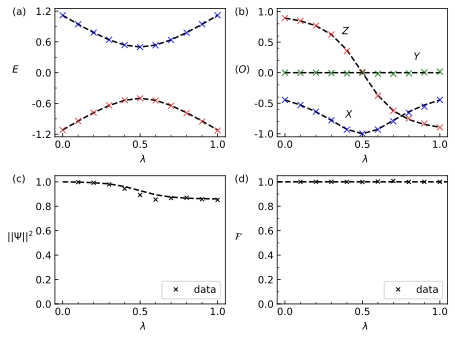

In [16]:
# draw figure
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf','svg')
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

cm    = 1.0/2.54
rat   = 1.5
width = 8.6*cm * 1.5
height = 8.6*cm  * 1.5
plt.figure(figsize=(width,height),dpi=600)

marker_style_ref = dict(marker='',linestyle='dashed',color='black')

marker_style_1_1  = dict(marker='s', linestyle='none', color='tab:red', alpha=0.4,  fillstyle='none')
marker_style_1_2  = dict(marker='s', linestyle='none', color='mediumblue', alpha=0.4,  fillstyle='none')
marker_style_1_3  = dict(marker='s', linestyle='none', color='darkgreen', alpha=0.4,  fillstyle='none')

marker_style_2_1  = dict(marker='D', linestyle='none', color='tab:red', alpha=0.6,  fillstyle='none')
marker_style_2_2  = dict(marker='D', linestyle='none', color='mediumblue', alpha=0.6,  fillstyle='none')
marker_style_2_3  = dict(marker='D', linestyle='none', color='darkgreen', alpha=0.6,  fillstyle='none')

marker_style_3_1  = dict(marker='x', linestyle='none', color='tab:red', alpha=0.8,  fillstyle='none')
marker_style_3_2  = dict(marker='x', linestyle='none', color='mediumblue', alpha=0.8,  fillstyle='none')
marker_style_3_3  = dict(marker='x', linestyle='none', color='darkgreen', alpha=0.8,  fillstyle='none')

marker_style_4  = dict(marker='s', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_5  = dict(marker='D', linestyle='none', color='black', alpha=1.0,  fillstyle='none')

marker_style_6  = dict(marker='x', linestyle='none', color='black', alpha=1.0,  fillstyle='none')


fig, axes = plt.subplots(2,2)

# plot (a)

y_min    = -1.25
y_max    =  1.25

x_min    =  -0.05
x_max    =  1.05

axes[0,0].set_xlim(x_min,x_max)
axes[0,0].set_ylim(y_min,y_max)
# setup labels
axes[0,0].text(-0.25,0.95,'(a)',transform=axes[0,0].transAxes)
axes[0,0].text(0.5,-0.2,r'$\lambda$',transform=axes[0,0].transAxes)
axes[0,0].text(-0.25,0.5,r'$E$',transform=axes[0,0].transAxes)
# setup tics
axes[0,0].tick_params(axis='x', which='both', direction='in')
axes[0,0].tick_params(axis='y', which='both', direction='in')
axes[0,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,0].xaxis.set_major_formatter('{x:0.1f}')
axes[0,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,0].yaxis.set_major_locator(ticker.MultipleLocator(0.6))
axes[0,0].yaxis.set_major_formatter('{x:0.1f}')
axes[0,0].yaxis.set_minor_locator(ticker.MultipleLocator(0.3))

# plot
axes[0,0].plot(lds,E_exact[:,0], label='', **marker_style_ref)
axes[0,0].plot(lds,E_exact[:,1], label='', **marker_style_ref)

axes[0,0].plot(lds,Emc[:,0], label='', markersize=6, **marker_style_3_1)
axes[0,0].plot(lds,Emc[:,1], label='', markersize=6, **marker_style_3_2)


# plot (b)
y_min    = -1.05
y_max    =  1.05

x_min    =  -0.05
x_max    =  1.05

axes[0,1].set_xlim(x_min,x_max)
axes[0,1].set_ylim(y_min,y_max)
# setup labels
axes[0,1].text(-0.25,0.95,'(b)',transform=axes[0,1].transAxes)
axes[0,1].text(0.5,-0.2,s=r'$\lambda$',transform=axes[0,1].transAxes)
axes[0,1].text(-0.25,0.5,s=r'$\langle O\rangle$',transform=axes[0,1].transAxes)


axes[0,1].text(0.4,0.15,s=r'$X$',transform=axes[0,1].transAxes)
axes[0,1].text(0.8,0.6,s=r'$Y$',transform=axes[0,1].transAxes)
axes[0,1].text(0.38,0.8,s=r'$Z$',transform=axes[0,1].transAxes)
# setup tics
axes[0,1].tick_params(axis='x', which='both', direction='in')
axes[0,1].tick_params(axis='y', which='both', direction='in')
axes[0,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].xaxis.set_major_formatter('{x:0.1f}')
axes[0,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

axes[0,1].yaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[0,1].yaxis.set_major_formatter('{x:0.1f}')
axes[0,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.2))

# plot
axes[0,1].plot(lds,Z_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,X_exact[:,0], label='', **marker_style_ref)
axes[0,1].plot(lds,Y_exact[:,0], label='', **marker_style_ref)

axes[0,1].plot(lds,Zmc[:,0], label ='', markersize=6, **marker_style_3_1)
axes[0,1].plot(lds,Xmc[:,0], label ='', markersize=6, **marker_style_3_2)
axes[0,1].plot(lds,Ymc[:,0], label ='', markersize=6, **marker_style_3_3)

# plot (c)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,0].set_xlim(x_min,x_max)
axes[1,0].set_ylim(y_min,y_max)
# setup labels
axes[1,0].text(-0.25,0.95,'(c)',transform=axes[1,0].transAxes)
axes[1,0].text(0.5,-0.2,r'$\lambda$',transform=axes[1,0].transAxes)
axes[1,0].text(-0.28,0.5,r'$||\Psi||^2$',transform=axes[1,0].transAxes)
# setup tics
axes[1,0].tick_params(axis='x', which='both', direction='in')
axes[1,0].tick_params(axis='y', which='both', direction='in')
axes[1,0].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,0].xaxis.set_major_formatter('{x:0.1f}')
axes[1,0].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,0].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,0].plot(lds,norm_exact[:,0], label='', **marker_style_ref)

axes[1,0].plot(lds[1:],normmc[1:,0], label='data', markersize=4, **marker_style_6)

axes[1,0].legend(loc='lower right')

# plot (d)
y_min    = 0.0
y_max    = 1.05

x_min    =  -0.05
x_max    =  1.05

axes[1,1].set_xlim(x_min,x_max)
axes[1,1].set_ylim(y_min,y_max)
# setup labels
axes[1,1].text(-0.25,0.95,'(d)',transform=axes[1,1].transAxes)
axes[1,1].text(0.5,-0.2,r'$\lambda$',transform=axes[1,1].transAxes)
axes[1,1].text(-0.25,0.5,r'$\mathcal{F}$',transform=axes[1,1].transAxes)
# setup tics
axes[1,1].tick_params(axis='x', which='both', direction='in')
axes[1,1].tick_params(axis='y', which='both', direction='in')
axes[1,1].xaxis.set_major_locator(ticker.MultipleLocator(0.5))
axes[1,1].xaxis.set_major_formatter('{x:0.1f}')
axes[1,1].xaxis.set_minor_locator(ticker.MultipleLocator(0.1))

#axes[1,1].set_yscale('log')
axes[1,1].yaxis.set_major_locator(ticker.MultipleLocator(0.2))
axes[1,1].yaxis.set_major_formatter('{x:0.1f}')
axes[1,1].yaxis.set_minor_locator(ticker.MultipleLocator(0.1))

# plot
axes[1,1].axhline(y=1.0, label='', **marker_style_ref)


axes[1,1].plot(lds[1:],Fmc[1:,0], label='data', markersize=4, **marker_style_6)
axes[1,1].legend(loc='lower right')

plt.tight_layout()